<a href="https://colab.research.google.com/github/Diego-1099/Colabfiles/blob/main/Tarea_8_Ajuste_de_modelos_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ajustar modelos AR, MA, ARIMA y SARIMA al dataset proporcionado**

**Instrucciones:**

**1.** Investigar sobre la implementación

**2.** Modificar el código proporcionado en el campus virtual (Código Python) para realizar lo siguiente:

>*   Leer el conjunto de datos proporcionado.
>*   Generar al menos ocho diferentes modelos como AR, MA, ARIMA, SARIMA, por ejemplo, AR(1), AR(2), AR(3), MA(1), …, SARIMA(2,1,2)(1, 1, 1, 12), SARIMA(2,1,2)(1, 1, 2, 12), etc., según los modelos que crean convenientes.
>*   c.	Implementar un GridSearch para generar modelos con diferentes parámetros como los mencionados en el inciso b (código que está como comentarios al final del script que está en el CV).

**3.** Identificar el mejor modelo en base a los criterios AIC y BIC.

**4.**	Visualizar los pronósticos de cada modelo en una gráfica independiente junto con los datos reales.

**5.**	Identificar el mejor modelo de acuerdo con las métricas MAE, MSE, RMSE, MAPE, sMAPE.

**Responde a las siguientes preguntas**

>* 	¿Cuál fue el mejor modelo en base a AIC y BIC?
>* 	¿Cuál fue el mejor modelo en base a las métricas MAE, MSE, RMSE, MAPE, sMAPE?
>* 	¿Cuál fue el mejor modelo considerando el análisis de residuos?
>* 	¿La serie de datos original era estacionaria o no?
>* 	¿Se tuvo que diferenciar la serie?
>* 	¿Cuántas veces?


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


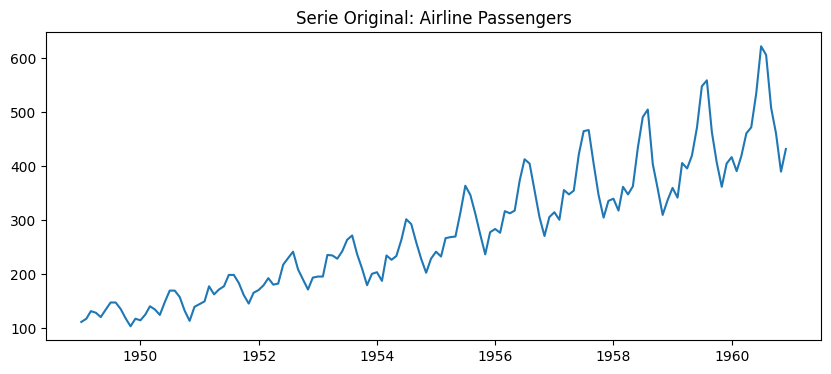

--- ANALISIS DE ESTACIONARIEDAD ORIGINAL ---
===>Test: ADF
H0: Serie NO estacionaria
H1: Serie estacionaria
p-value: 0.991880
NO se rechaza H0. No hay evidencia suficiente contra: Serie NO estacionaria

===>Test: KPSS
H0: Serie estacionaria
H1: Serie NO estacionaria
p-value: 0.010000
Se RECHAZA H0. Evidencia a favor de: Serie NO estacionaria

--- ANALISIS DE ESTACIONARIEDAD (DIFERENCIADA d=1) ---
===>Test: ADF
H0: Serie NO estacionaria
H1: Serie estacionaria
p-value: 0.054213
NO se rechaza H0. No hay evidencia suficiente contra: Serie NO estacionaria

===>Test: KPSS
H0: Serie estacionaria
H1: Serie NO estacionaria
p-value: 0.100000
NO se rechaza H0. No hay evidencia suficiente contra: Serie estacionaria

Iniciando GridSearch... (Esto puede tardar unos segundos)
MEJOR CONFIGURACIÓN ENCONTRADA: ((1, 1, 1), (1, 1, 1, 12)) AIC: 657.60

--- RESULTADOS AIC | BIC (Instrucción 3) ---


,Modelo,AIC,BIC
6,SARIMA_Grid,758.260201,771.385065
7,SARIMA_Manual,758.260201,771.385065
5,"ARIMA(2,1,2)",1057.516178,1071.197170
4,"ARIMA(1,1,1)",1058.245574,1066.454169
3,MA(2),1060.685498,1068.894094
2,MA(1),1063.645793,1069.118190
1,AR(2),1065.642154,1073.850749
0,AR(1),1068.535806,1074.008203



--- COMPARATIVA DE MÉTRICAS (Instrucción 5) ---


,Modelo,MAE,MSE,RMSE,MAPE,sMAPE
6,SARIMA_Grid,23.555745,908.540654,30.142008,5.052723,5.188850
7,SARIMA_Manual,23.555745,908.540654,30.142008,5.052723,5.188850
5,"ARIMA(2,1,2)",63.545311,6808.397034,82.513011,14.216159,14.305902
1,AR(2),76.241019,7799.129010,88.312678,18.759431,17.002654
3,MA(2),77.198616,7969.713539,89.273252,19.034881,17.198182
4,"ARIMA(1,1,1)",85.254156,9506.175842,97.499620,21.291349,18.812238
2,MA(1),88.392132,10215.151724,101.070034,22.166667,19.425705
0,AR(1),94.000695,11496.091370,107.219827,23.689205,20.504894


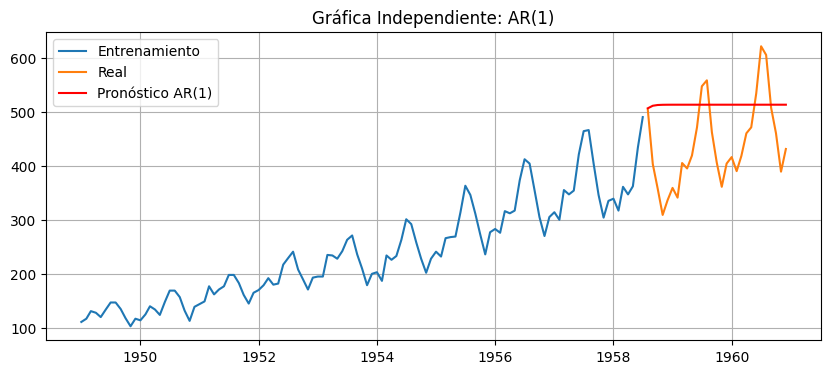

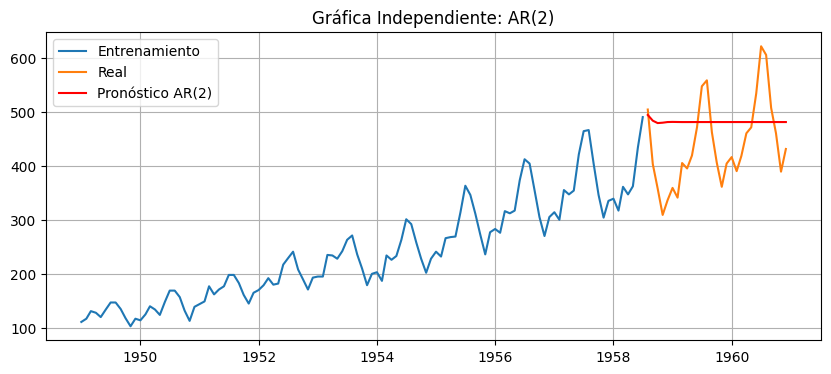

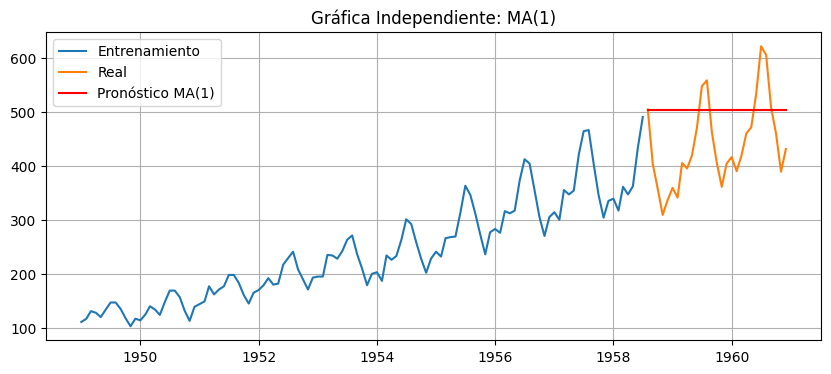

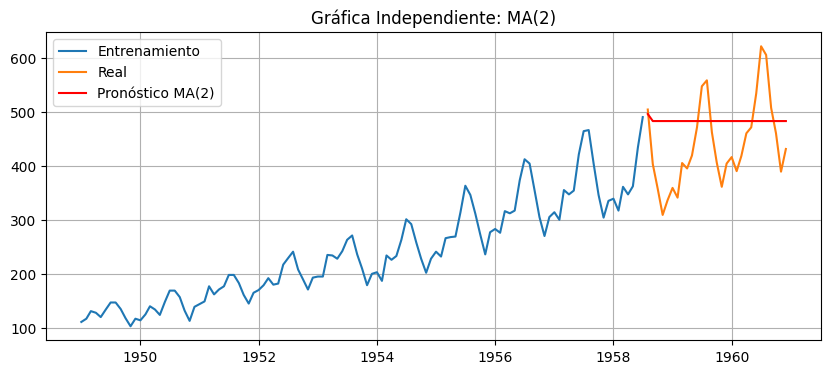

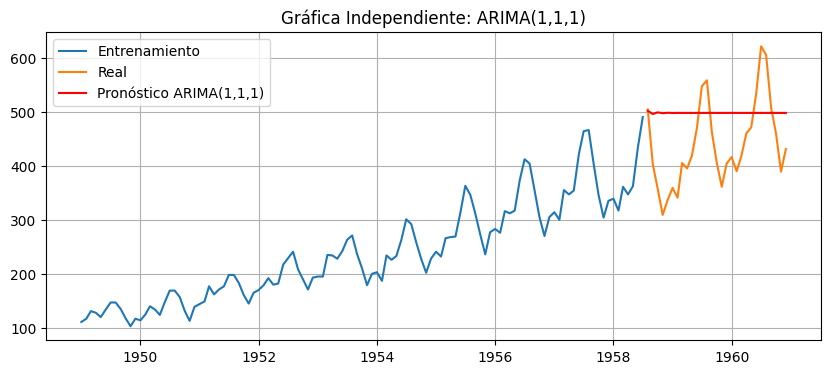

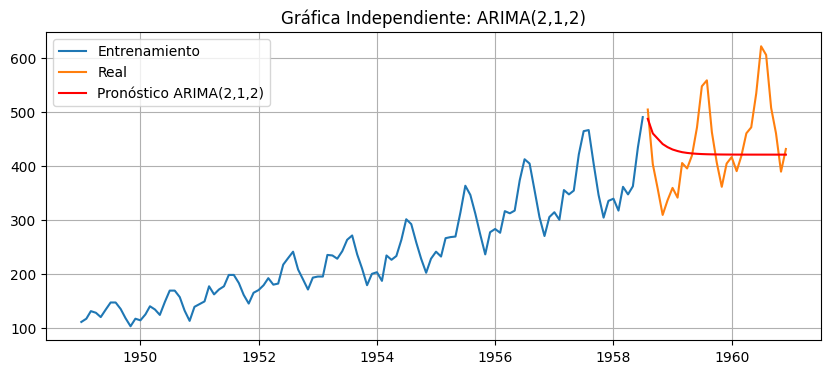

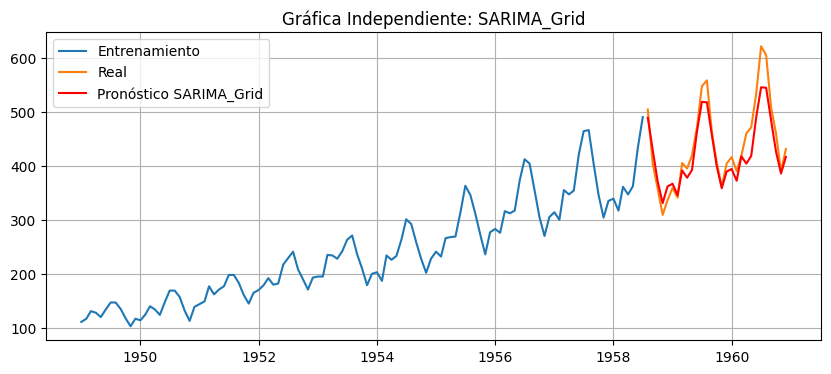

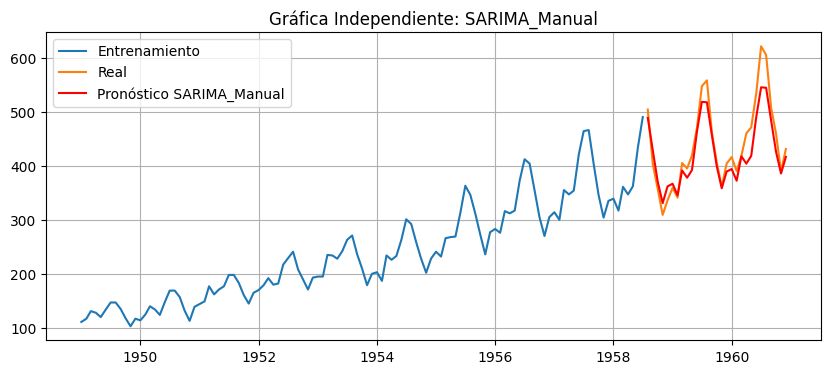

'\n--- ANÁLISIS DE RESIDUOS DEL MEJOR MODELO (SARIMA_Grid) ---'

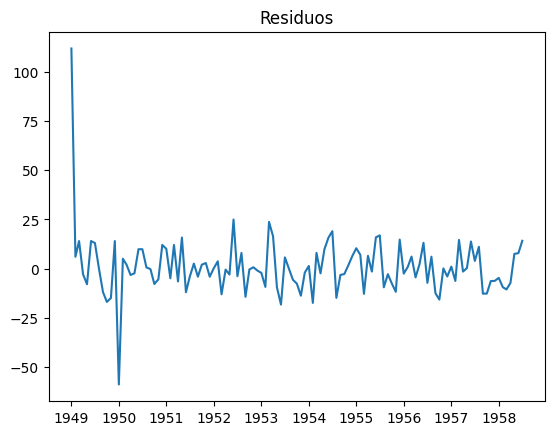

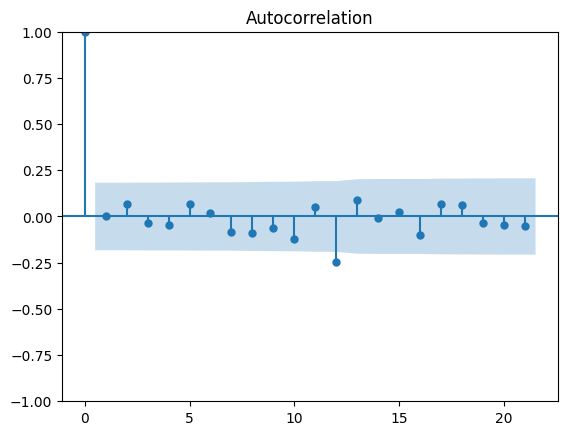

===>Test: Ljung-Box
H0: Ruido blanco
H1: Autocorrelación
p-value: 0.833535
NO se rechaza H0. No hay evidencia suficiente contra: Ruido blanco



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

# Configuración de visualización
DEBUG_SHOW_GRAPH = True
DEBUG_SHOW_GRAPH_CORRELOGRAM = True
DEBUG_SHOW_GRAPH_RESIDUALS = True

# --- FUNCIONES ---
def interpretar_test(nombre, pvalue, alpha, H0, H1):
    print(f"===>Test: {nombre}")
    print(f"H0: {H0}")
    print(f"H1: {H1}")
    print(f"p-value: {pvalue:.6f}")
    if pvalue < alpha:
        print("Se RECHAZA H0. Evidencia a favor de:", H1)
    else:
        print("NO se rechaza H0. No hay evidencia suficiente contra:", H0)
    print("")

def adf_test(series):
    result = adfuller(series.dropna())
    interpretar_test("ADF", result[1], 0.05, "Serie NO estacionaria", "Serie estacionaria")

def kpss_test(series):
    result = kpss(series.dropna(), regression = 'c', nlags = 'auto')
    interpretar_test("KPSS", result[1], 0.05, "Serie estacionaria", "Serie NO estacionaria")

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, mse, rmse, mape, smape

# --- EJECUCIÓN PRINCIPAL ---
if __name__ == "__main__":
    # 2a. Leer el conjunto de datos
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Resources/airline-passengers.csv')
    df['Month'] = pd.to_datetime(df['Month'])
    df.set_index('Month', inplace = True)
    ts = df['Passengers']
    n = len(ts)

    if DEBUG_SHOW_GRAPH:
        plt.figure(figsize = (10, 4))
        plt.plot(ts)
        plt.title("Serie Original: Airline Passengers")
        plt.show()

    # Pruebas de Estacionariedad Iniciales
    print("--- ANALISIS DE ESTACIONARIEDAD ORIGINAL ---")
    adf_test(ts)
    kpss_test(ts)

    # Diferenciación (Para responder preguntas 5 y 6)
    ts_diff = ts.diff().dropna()
    print("--- ANALISIS DE ESTACIONARIEDAD (DIFERENCIADA d=1) ---")
    adf_test(ts_diff)
    kpss_test(ts_diff)

    # División 80% Train - 20% Test
    train_size = int(len(ts) * 0.8)
    train, test = ts[:train_size], ts[train_size:]

    # 2c. GridSearch (Basado en comentarios del maestro)
    print("Iniciando GridSearch... (Esto puede tardar unos segundos)")
    p = d = q = range(0, 2)
    pdq = list(itertools.product(p, d, q))
    seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

    best_aic = float("inf")
    best_cfg = None

    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                # Usamos SARIMAX (Punto 1: Investigación SARIMA)
                res = SARIMAX(train, order = param, seasonal_order = param_seasonal,
                             enforce_stationarity = False, enforce_invertibility = False).fit(disp = False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_cfg = (param, param_seasonal)
            except: continue

    print(f"MEJOR CONFIGURACIÓN ENCONTRADA: {best_cfg} AIC: {best_aic:.2f}\n")

    # 2b. Generar al menos 8 modelos
    models = {}
    models["AR(1)"] = ARIMA(train, order = (1,1,0)).fit()
    models["AR(2)"] = ARIMA(train, order = (2,1,0)).fit()
    models["MA(1)"] = ARIMA(train, order = (0,1,1)).fit()
    models["MA(2)"] = ARIMA(train, order = (0,1,2)).fit()
    models["ARIMA(1,1,1)"] = ARIMA(train, order = (1,1,1)).fit()
    models["ARIMA(2,1,2)"] = ARIMA(train, order = (2,1,2)).fit()
    models["SARIMA_Grid"] = SARIMAX(train, order = best_cfg[0], seasonal_order = best_cfg[1]).fit(disp = False)
    models["SARIMA_Manual"] = SARIMAX(train, order = (1,1,1), seasonal_order = (1,1,1,12)).fit(disp = False)

    # 3. Identificar mejor modelo por AIC y BIC
    results_list = []
    for name, model in models.items():
        results_list.append([name, model.aic, model.bic])
    df_results = pd.DataFrame(results_list, columns=["Modelo", "AIC", "BIC"]).sort_values("AIC")
    print("--- RESULTADOS AIC | BIC (Instrucción 3) ---")
    display(df_results)

    # 5. Identificar mejor modelo por Métricas de Error
    metrics_list = []
    pronosticos = {}
    for name, model in models.items():
        pred = model.get_forecast(steps=len(test)).predicted_mean
        pred_series = pd.Series(pred.values, index=test.index)
        pronosticos[name] = pred_series
        m = metrics(test, pred_series)
        metrics_list.append([name, m[0], m[1], m[2], m[3], m[4]])

    df_metrics = pd.DataFrame(metrics_list, columns = ["Modelo","MAE","MSE","RMSE","MAPE","sMAPE"])
    print("\n--- COMPARATIVA DE MÉTRICAS (Instrucción 5) ---")
    display(df_metrics.sort_values("MAPE"))

    # 4. Gráficas independientes
    for name, pred in pronosticos.items():
        plt.figure(figsize=(10, 4))
        plt.plot(train, label = "Entrenamiento")
        plt.plot(test, label = "Real")
        plt.plot(pred, label = f"Pronóstico {name}", color='red')
        plt.title(f"Gráfica Independiente: {name}")
        plt.legend(); plt.grid(True); plt.show()

    # Análisis de Residuos del MEJOR modelo según AIC
    mejor_nombre = df_results.iloc[0]['Modelo']
    resid = models[mejor_nombre].resid
    display(f"\n--- ANÁLISIS DE RESIDUOS DEL MEJOR MODELO ({mejor_nombre}) ---")

    if DEBUG_SHOW_GRAPH_RESIDUALS:
        plt.figure(); plt.plot(resid); plt.title("Residuos"); plt.show()
        plot_acf(resid); plt.show()

    lb_p = acorr_ljungbox(resid, lags = [10], return_df = True)["lb_pvalue"].values[0]
    interpretar_test("Ljung-Box", lb_p, 0.05, "Ruido blanco", "Autocorrelación")